In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving routing_evaluation_dataset.csv to routing_evaluation_dataset.csv
Saving model_routing_benchmark_summary.csv to model_routing_benchmark_summary.csv
Saving model_routing_benchmark.csv to model_routing_benchmark.csv
Saving cost_aware_rag_end_to_end.csv to cost_aware_rag_end_to_end.csv


In [ ]:
benchmark_df = pd.read_csv("/content/model_routing_benchmark.csv")
end_to_end_df = pd.read_csv("/content/cost_aware_rag_end_to_end.csv")
routing_df = pd.read_csv("/content/routing_evaluation_dataset.csv")
print("Benchmark rows:", len(benchmark_df))
print("End-to-end rows:", len(end_to_end_df))
print("Routing rows:", len(routing_df))

Benchmark rows: 20
End-to-end rows: 20
Routing rows: 20


In [ ]:
import os
for filename in [
    "model_routing_benchmark.csv",
    "cost_aware_rag_end_to_end.csv",
    "routing_evaluation_dataset.csv"
]:
    print(filename, "→", os.path.exists("/content/" + filename))

model_routing_benchmark.csv → True
cost_aware_rag_end_to_end.csv → True
routing_evaluation_dataset.csv → True


In [ ]:
workload_queries = (benchmark_df["query"].iloc[:10].tolist() * 2)
print("Total requests:", len(workload_queries))
print("Unique query strings:", len(set(workload_queries)))

Total requests: 20
Unique query strings: 10


In [ ]:
small_cost_lookup = (
    benchmark_df.set_index("query")["small_cost"].to_dict()
)
large_cost_lookup = (
    benchmark_df.set_index("query")["large_cost"].to_dict()
)

In [ ]:
always_20b_cost = sum(
    small_cost_lookup[query]
    for query in workload_queries
)
print("Always 20B cost: $",round(always_20b_cost, 6))

Always 20B cost: $ 0.00411


In [ ]:
always_120b_cost = sum(
    large_cost_lookup[query]
    for query in workload_queries
)
print("Always 120B cost: $",round(always_120b_cost, 6))

Always 120B cost: $ 0.008408


In [ ]:
unique_workload_queries = list(dict.fromkeys(workload_queries))
cache_only_cost = sum(large_cost_lookup[query]
    for query in unique_workload_queries
)
print("Semantic Cache Only cost: $",round(cache_only_cost, 6))

Semantic Cache Only cost: $ 0.004204


In [ ]:
router_prediction_lookup = (
    routing_df.set_index("query")["router_prediction"].to_dict()
)

In [ ]:
router_only_cost = 0
for query in workload_queries:
    prediction = router_prediction_lookup[query]
    if prediction == 1:
        router_only_cost += small_cost_lookup[query]
    else:
        router_only_cost += large_cost_lookup[query]
print(
    "Router Only cost: $",round(router_only_cost, 6)
)

Router Only cost: $ 0.006831


In [ ]:
cache_router_cost = end_to_end_df["estimated_cost"].sum()
print("Cache + Router cost: $",round(cache_router_cost, 6))

Cache + Router cost: $ 0.003025


In [ ]:
ablation_results = pd.DataFrame({
    "System": [
        "Always 20B","Always 120B",
        "Semantic Cache Only","Router Only",
        "Semantic Cache + Router"
    ],
    "Total Estimated Cost": [
        always_20b_cost,always_120b_cost,
        cache_only_cost,router_only_cost,
        cache_router_cost
    ]
})
ablation_results["Cost Reduction vs 120B (%)"] = (
    1 - ablation_results["Total Estimated Cost"] / always_120b_cost
) * 100
ablation_results

,System,Total Estimated Cost,Cost Reduction vs 120B (%)
0,Always 20B,0.004110,51.120388
1,Always 120B,0.008408,0.000000
2,Semantic Cache Only,0.004204,50.000000
3,Router Only,0.006831,18.754014
4,Semantic Cache + Router,0.003025,64.026261


In [ ]:
ablation_results["Relative Cost"] = (
    ablation_results["Total Estimated Cost"] / always_120b_cost
)
ablation_results

,System,Total Estimated Cost,Cost Reduction vs 120B (%),Relative Cost
0,Always 20B,0.004110,51.120388,0.488796
1,Always 120B,0.008408,0.000000,1.000000
2,Semantic Cache Only,0.004204,50.000000,0.500000
3,Router Only,0.006831,18.754014,0.812460
4,Semantic Cache + Router,0.003025,64.026261,0.359737


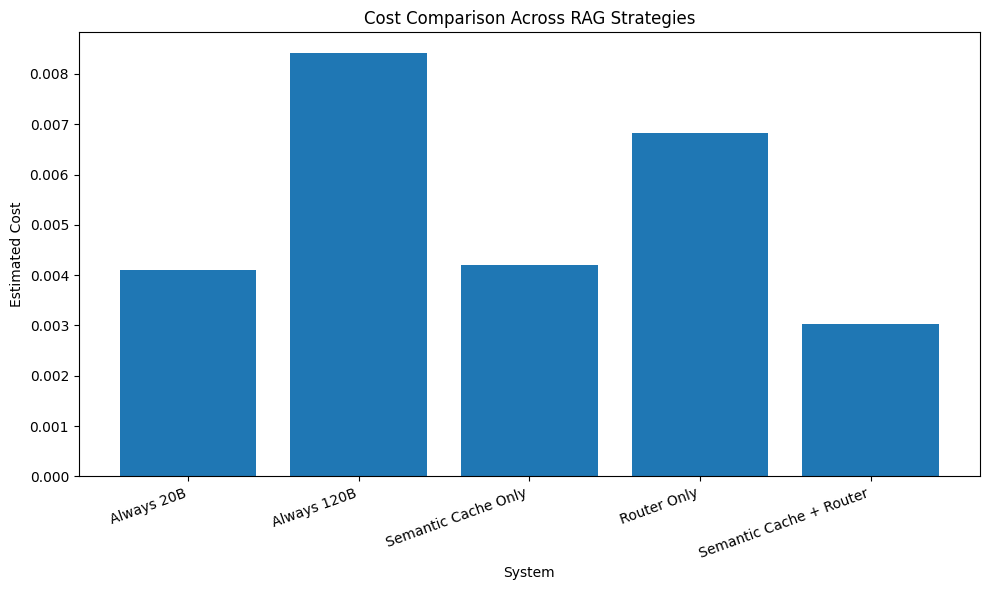

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(
    ablation_results["System"],ablation_results["Total Estimated Cost"]
)
plt.ylabel("Estimated Cost")
plt.xlabel("System")
plt.title("Cost Comparison Across RAG Strategies")
plt.xticks(rotation=20,ha="right")
plt.tight_layout()
plt.show()

In [ ]:
cache_hits = int(end_to_end_df["cache_hit"].sum())
total_requests = len(end_to_end_df)
cache_hit_rate = (
    cache_hits /total_requests
) * 100
llm_calls_avoided = cache_hits
print(
    "Total requests:",total_requests
)
print(
    "Cache hits:",cache_hits
)
print(
    "Cache hit rate:",round(cache_hit_rate, 2),"%"
)
print(
    "LLM calls avoided:",llm_calls_avoided
)

Total requests: 20
Cache hits: 11
Cache hit rate: 55.0 %
LLM calls avoided: 11


In [ ]:
cache_misses = end_to_end_df[~end_to_end_df["cache_hit"]]
routing_distribution = (cache_misses["selected_model"].value_counts())
routing_distribution

,count
selected_model,
openai/gpt-oss-120b,5
openai/gpt-oss-20b,4


In [ ]:
routing_percentages = (routing_distribution /routing_distribution.sum()
) * 100
routing_percentages

,count
selected_model,
openai/gpt-oss-120b,55.555556
openai/gpt-oss-20b,44.444444


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
small_answer_embeddings = embedding_model.encode(
    benchmark_df["small_answer"].tolist(),
    batch_size=16,normalize_embeddings=True
).astype("float32")
large_answer_embeddings = embedding_model.encode(
    benchmark_df["large_answer"].tolist(),
    batch_size=16,normalize_embeddings=True
).astype("float32")
answer_similarity = np.sum(
    small_answer_embeddings * large_answer_embeddings,axis=1
)
benchmark_df["answer_similarity"] = answer_similarity
print("answer_similarity created successfully.")
print(benchmark_df["answer_similarity"].describe())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

answer_similarity created successfully.
count    20.000000
mean      0.867138
std       0.097629
min       0.635374
25%       0.860447
50%       0.896867
75%       0.921866
max       0.975927
Name: answer_similarity, dtype: float64


In [ ]:
benchmark_df[
    [
        "query","small_answer","large_answer","answer_similarity"
    ]
].head()

,query,small_answer,large_answer,answer_similarity
0,0-dimensional biomaterials lack inductive prop...,The provided context does not contain informat...,The provided documents do not contain informat...,0.878049
1,1 in 5 million in UK have abnormal PrP positiv...,The data from the large‑scale appendix survey ...,The statement is not supported by the data. In...,0.635374
2,1-1% of colorectal cancer patients are diagnos...,No. In the Dutch nationwide study (1996‑2011) ...,The documents do not support the claim that on...,0.887530
3,10% of sudden infant death syndrome (SIDS) dea...,"I’m sorry, but the provided documents do not c...",The provided documents do not contain any data...,0.899179
4,32% of liver transplantation programs required...,"Yes. According to the study, 32 % of liver‑tra...",The provided documents state that 32 percent o...,0.822267


In [ ]:
final_system_summary = pd.DataFrame({
    "Metric": [
        "Total requests","Cache hit rate (%)",
        "LLM calls","20B calls",
        "120B calls","Always-120B cost",
        "Final system cost","Cost saved",
        "Cost reduction (%)","Average 20B/120B answer similarity"
    ],
    "Value": [
        len(end_to_end_df),cache_hit_rate,len(cache_misses),
        int(
            (
                cache_misses["selected_model"] == "openai/gpt-oss-20b"
            ).sum()
        ),
        int(
            (
                cache_misses["selected_model"] == "openai/gpt-oss-120b"
            ).sum()
        ),
        always_120b_cost,cache_router_cost,
        always_120b_cost - cache_router_cost,
        (
            1 -cache_router_cost / always_120b_cost
        ) * 100,
        benchmark_df["answer_similarity"].mean()]
})
final_system_summary

,Metric,Value
0,Total requests,20.000000
1,Cache hit rate (%),55.000000
2,LLM calls,9.000000
3,20B calls,4.000000
4,120B calls,5.000000
5,Always-120B cost,0.008408
6,Final system cost,0.003025
7,Cost saved,0.005383
8,Cost reduction (%),64.026261
9,Average 20B/120B answer similarity,0.867138


In [ ]:
ablation_results.to_csv(
    "final_ablation_results.csv",index=False
)
final_system_summary.to_csv(
    "final_system_summary.csv",index=False
)
routing_percentages.to_csv(
    "final_routing_distribution.csv"
)
print("Final experiment results saved.")

Final experiment results saved.


In [ ]:
ablation_results

,System,Total Estimated Cost,Cost Reduction vs 120B (%),Relative Cost
0,Always 20B,0.004110,51.120388,0.488796
1,Always 120B,0.008408,0.000000,1.000000
2,Semantic Cache Only,0.004204,50.000000,0.500000
3,Router Only,0.006831,18.754014,0.812460
4,Semantic Cache + Router,0.003025,64.026261,0.359737


In [ ]:
ablation_results.sort_values("Total Estimated Cost")

,System,Total Estimated Cost,Cost Reduction vs 120B (%),Relative Cost
4,Semantic Cache + Router,0.003025,64.026261,0.359737
0,Always 20B,0.004110,51.120388,0.488796
2,Semantic Cache Only,0.004204,50.000000,0.500000
3,Router Only,0.006831,18.754014,0.812460
1,Always 120B,0.008408,0.000000,1.000000


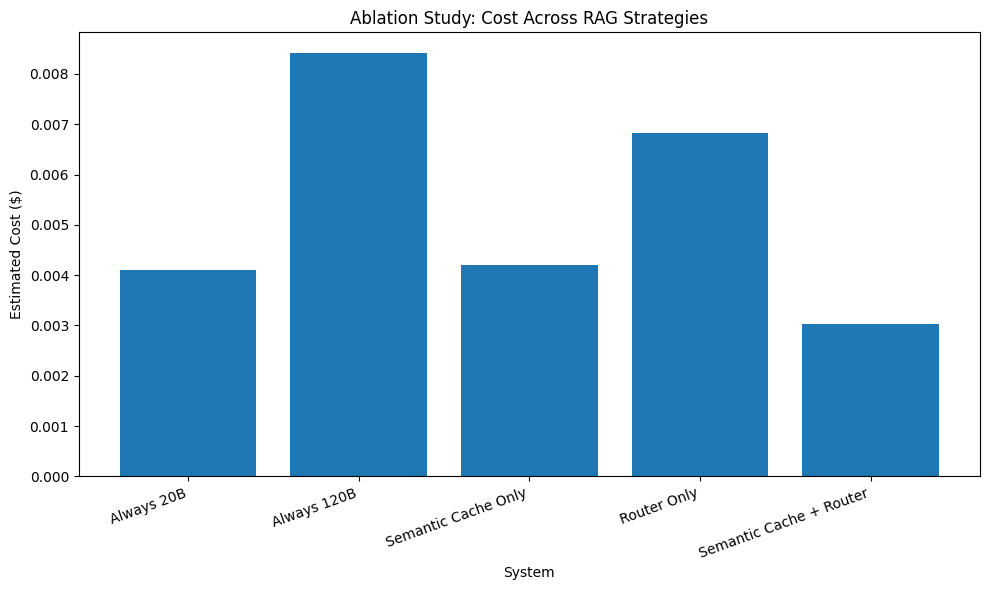

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(
    ablation_results["System"],ablation_results["Total Estimated Cost"]
)
plt.ylabel("Estimated Cost ($)")
plt.xlabel("System")
plt.title("Ablation Study: Cost Across RAG Strategies")
plt.xticks(rotation=20,ha="right")
plt.tight_layout()
plt.savefig(
    "final_ablation_cost.png",dpi=300,bbox_inches="tight"
)
plt.show()

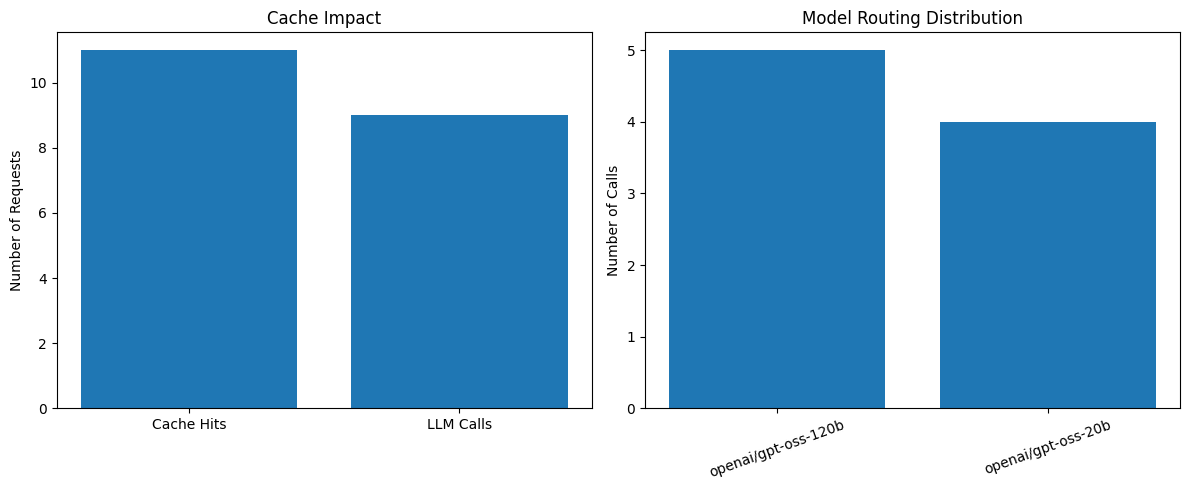

In [ ]:
fig, axes = plt.subplots(1, 2,figsize=(12, 5))
axes[0].bar(
    ["Cache Hits", "LLM Calls"],
    [cache_hits,len(cache_misses)]
)
axes[0].set_title("Cache Impact")
axes[0].set_ylabel("Number of Requests")
axes[1].bar(routing_distribution.index,routing_distribution.values)
axes[1].set_title("Model Routing Distribution")
axes[1].set_ylabel("Number of Calls")
axes[1].tick_params(axis="x",rotation=20)
plt.tight_layout()
plt.savefig("final_cache_routing.png",dpi=300,bbox_inches="tight")
plt.show()

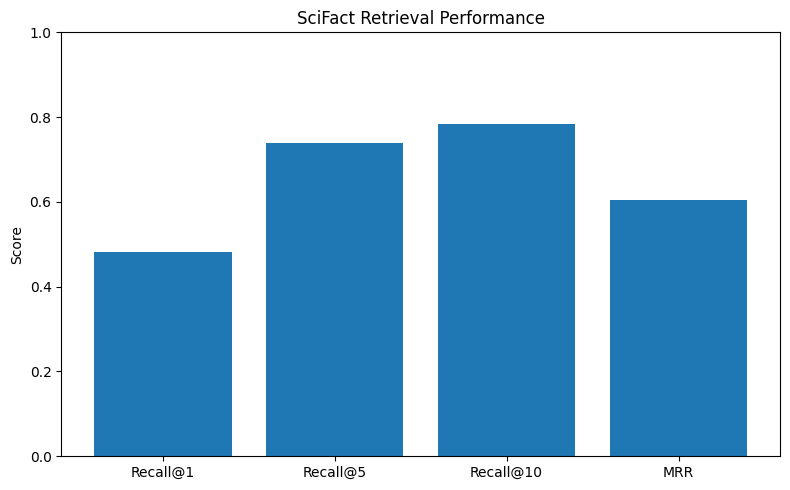

In [ ]:
metrics_to_plot = pd.DataFrame({
    "Metric": [
        "Recall@1","Recall@5",
        "Recall@10","MRR"
    ],
    "Score": [
        0.482333,0.737944,0.783333,0.604725
    ]
})
plt.figure(figsize=(8, 5))
plt.bar(
    metrics_to_plot["Metric"],metrics_to_plot["Score"]
)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("SciFact Retrieval Performance")
plt.tight_layout()
plt.savefig(
    "final_retrieval_metrics.png",dpi=300,bbox_inches="tight"
)
plt.show()

In [ ]:
ablation_results


,System,Total Estimated Cost,Cost Reduction vs 120B (%),Relative Cost
0,Always 20B,0.004110,51.120388,0.488796
1,Always 120B,0.008408,0.000000,1.000000
2,Semantic Cache Only,0.004204,50.000000,0.500000
3,Router Only,0.006831,18.754014,0.812460
4,Semantic Cache + Router,0.003025,64.026261,0.359737


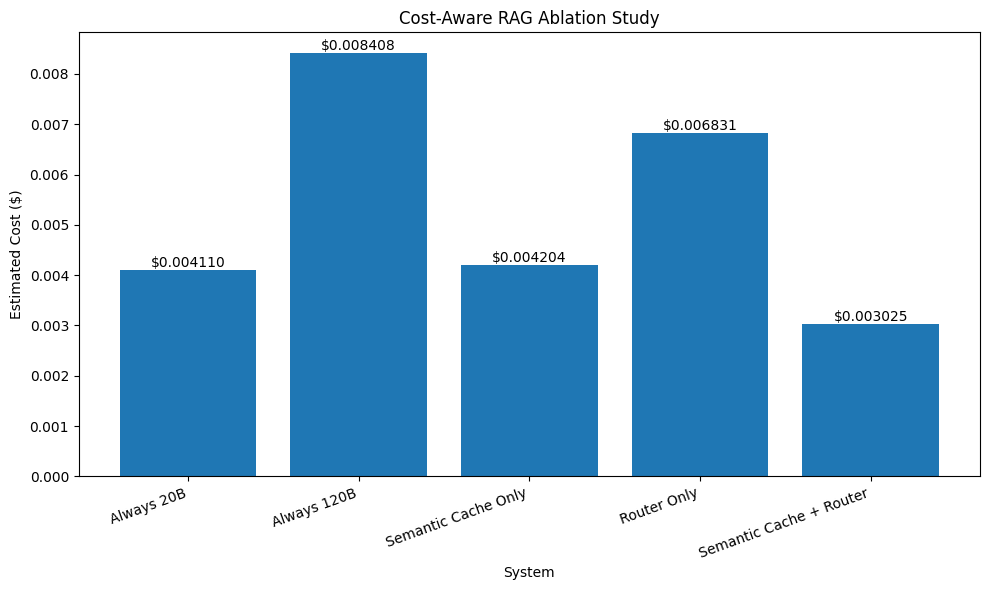

In [ ]:
plt.figure(figsize=(10, 6))
bars = plt.bar(
    ablation_results["System"],
    ablation_results["Total Estimated Cost"]
)
plt.ylabel("Estimated Cost ($)")
plt.xlabel("System")
plt.title("Cost-Aware RAG Ablation Study")
plt.xticks(rotation=20,ha="right")
for bar, cost in zip(
    bars,ablation_results["Total Estimated Cost"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),f"${cost:.6f}",ha="center",va="bottom"
    )
plt.tight_layout()
plt.savefig(
    "final_ablation_cost.png",dpi=300,bbox_inches="tight"
)
plt.show()

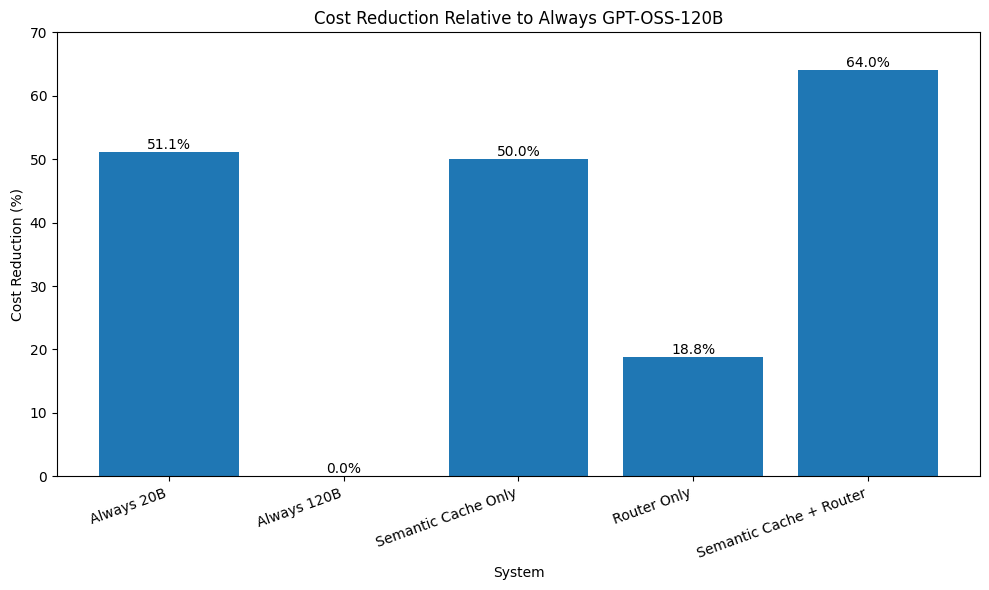

In [ ]:
plt.figure(figsize=(10, 6))
bars = plt.bar(
    ablation_results["System"],
    ablation_results["Cost Reduction vs 120B (%)"]
)
plt.ylabel("Cost Reduction (%)")
plt.xlabel("System")
plt.title("Cost Reduction Relative to Always GPT-OSS-120B")
plt.xticks(rotation=20,ha="right")
plt.ylim(0, 70)
for bar, reduction in zip(
    bars,ablation_results["Cost Reduction vs 120B (%)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{reduction:.1f}%",
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.savefig(
    "final_cost_reduction.png",
    dpi=300,bbox_inches="tight"
)
plt.show()

In [ ]:
final_experiment_report = pd.DataFrame({
    "Metric": [
        "Retrieval Recall@1","Retrieval Recall@5",
        "Retrieval Recall@10","Retrieval MRR",
        "Cache Hit Rate","Total Requests",
        "LLM Calls","20B Calls",
        "120B Calls","Average Answer Similarity",
        "Always 120B Cost","Final System Cost",
        "Cost Reduction"
    ],
    "Value": [
        0.482333,0.737944,0.783333,0.604725,55.0,20,9,4,5,0.867138,
        0.008408,0.003025,64.026261
    ]
})
final_experiment_report.to_csv(
    "final_experiment_report.csv",index=False
)
final_experiment_report

,Metric,Value
0,Retrieval Recall@1,0.482333
1,Retrieval Recall@5,0.737944
2,Retrieval Recall@10,0.783333
3,Retrieval MRR,0.604725
4,Cache Hit Rate,55.000000
5,Total Requests,20.000000
6,LLM Calls,9.000000
7,20B Calls,4.000000
8,120B Calls,5.000000
9,Average Answer Similarity,0.867138
